# NLP Project 2
**ESILV A4 DIA6 — 2026**

**Authors:** Leo WINTER & Alvaro SERERO

## Table of Contents
1. [Setup & Imports](#setup)
2. [Load & Merge Data](#load)
3. [Exploratory Data Analysis](#eda)
   - 3.1 [Rating Distribution](#rating)
   - 3.2 [Reviews per Insurer](#insurer)
   - 3.3 [Reviews per Product Type](#product)
   - 3.4 [Average Rating per Insurer](#avg_rating)
   - 3.5 [Review Length Analysis](#review_length)
   - 3.6 [Reviews Over Time](#time)
4. [Frequent Words & N-grams](#ngrams)
5. [Data Cleaning](#cleaning)
6. [Conclusion](#conclusion)

📋 Project Roadmap (in recommended order)
- Step 1 — Data Cleaning & EDA
-       Load all 35 files, merge, visualize distributions, find frequent words/n-grams, and do spelling correction to fill avis_cor
- Step 2 — Summary, Translation & Generation
-       Use a model (e.g. HuggingFace) to produce clean summaries and populate avis_cor_en
- Step 3 — Topic Modeling
-       LDA or BERTopic to find themes in reviews (pricing, service, claims, etc.)
- Step 4 — Embeddings
-       Train Word2Vec, use GloVe, visualize with Matplotlib/TensorBoard, implement semantic search
- Step 5 — Supervised Learning (star rating prediction)
-       TF-IDF + classical ML → Basic embedding model → Pre-trained embeddings → BERT/USE/LLM
- Step 6 — Streamlit Apps
-       Prediction app + Insurer analysis dashboard

## 0. Dependencies

In [27]:
# !pip install pandas openpyxl matplotlib seaborn wordcloud textblob deep-translator tqdm nlpclean

## 1. Setup & Imports

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from nltk.corpus import stopwords
import nltk
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
from spellchecker import SpellChecker
from textblob import TextBlob
from tqdm.auto import tqdm

# Ensure the visualizations directory exists
Path("visualizations").mkdir(exist_ok=True)

# Downloading model for cleaning the text
nltk.download('stopwords')
nltk.download('punkt')
STOP_WORDS_FR = set(stopwords.words('french'))
STOP_WORDS_EN = set(stopwords.words('english'))
MODEL_CORRECTION_FR = SpellChecker(language='fr')
MODEL_CORRECTION_EN = SpellChecker(language='en')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/alvaro/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/alvaro/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## 2. Load & Merge Data

The dataset consists of 35 Excel files, each containing client reviews for an insurance product. We will load all these files, merge them into a single DataFrame, and perform an initial exploration to understand the structure and content of the data.

The dataset contains the following columns:

| Column | Description                                         |
| :--- |:----------------------------------------------------|
| `note` | Star rating 1–5 (main prediction target)            |
| `avis` | Original review in French                           |
| `avis_en` | Automatic translation of the review to English      |
| `avis_cor` | Corrected French review                             |
| `avis_cor_en` | Corrected and translated English review             |
| `assureur` | Insurance company name                              |
| `produit` | Insurance product type (auto, santé, animaux, etc.) |
| `date_publication` | Review date                                         |

In [ ]:
# Current directory
CURRENT_DIR = Path.cwd()

# Path to the data directory containing the Excel files
DATA_PATH = CURRENT_DIR / "data"

def read_dataset(n:int=35) -> list[pd.DataFrame]:
    dataset_list = []
    for i in range(1, n + 1):
        try:
            file_name = f"avis_{i}_traduit.xlsx"
            dataset_list.append(pd.read_excel(DATA_PATH / file_name, engine="openpyxl"))
        except Exception as e:
            print(f"Error when reading the {file_name} ->{e}")
    return dataset_list

def fusion_dataset(dataset_list: list[pd.DataFrame])-> pd.DataFrame:
    try:
        df_final = pd.concat(dataset_list, ignore_index=True)
        return df_final
    except Exception as e:
        print(f"Error  : {e}")
        return pd.DataFrame()

With pandas, we need to have openpyxl installed to read an .xlsx file

In [30]:
dataset_list= read_dataset()
print(f"Found {len(dataset_list)} Excel files")

Found 35 Excel files


In [31]:
df = fusion_dataset(dataset_list)
df.head(5)

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,5.0,brahim--k-131532,"Meilleurs assurances, prix, solutions, écoute,...",Direct Assurance,auto,train,06/09/2021,01/09/2021,"Best insurance, price, solutions, listening, s...",NaN,NaN
1,4.0,bernard-g-112497,"je suis globalement satisfait , sauf que vous ...",Direct Assurance,auto,train,03/05/2021,01/05/2021,"I am generally satisfied, except that you have...",NaN,NaN
2,5.0,virginie-t-107352,Prix tres abordable plusieurs options s'offren...,Direct Assurance,auto,train,21/03/2021,01/03/2021,Very affordable price Several options are avai...,NaN,NaN
3,4.0,boulain-f-116580,"je satisfait du service, une réponse très rapi...",L'olivier Assurance,auto,train,10/06/2021,01/06/2021,"I satisfy the service, a very fast response fr...",NaN,NaN
4,1.0,ouaille31-51798,"Client depuis plus de 25 ans, très déçu de cet...",Matmut,auto,train,29/01/2017,01/01/2017,"Customer for more than 25 years, very disappoi...",NaN,NaN


In [32]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (34435, 11)

Dtypes:
 note                float64
auteur                  str
avis                    str
assureur                str
produit                 str
type                    str
date_publication        str
date_exp                str
avis_en                 str
avis_cor             object
avis_cor_en          object
dtype: object

Missing values:
 note                10331
auteur                  1
avis                    0
assureur                0
produit                 0
type                    0
date_publication        0
date_exp                0
avis_en                 2
avis_cor            34000
avis_cor_en         34004
dtype: int64

Duplicate rows: 5


In [34]:
display(df.describe(include='all').loc[['count', 'unique',]].T)

,count,unique
note,24104.0,NaN
auteur,34434,33569
avis,34435,34377
assureur,34435,56
produit,34435,13
type,34435,2
date_publication,34435,1815
date_exp,34435,61
avis_en,34433,33264
avis_cor,34435,34356


## 3. Exploratory Data Analysis

### 3.1 Rating Distribution

In [36]:
note_counts = df["note"].value_counts().sort_index()
note_counts

note
1.0    7271
2.0    3716
3.0    3382
4.0    4885
5.0    4850
Name: count, dtype: int64

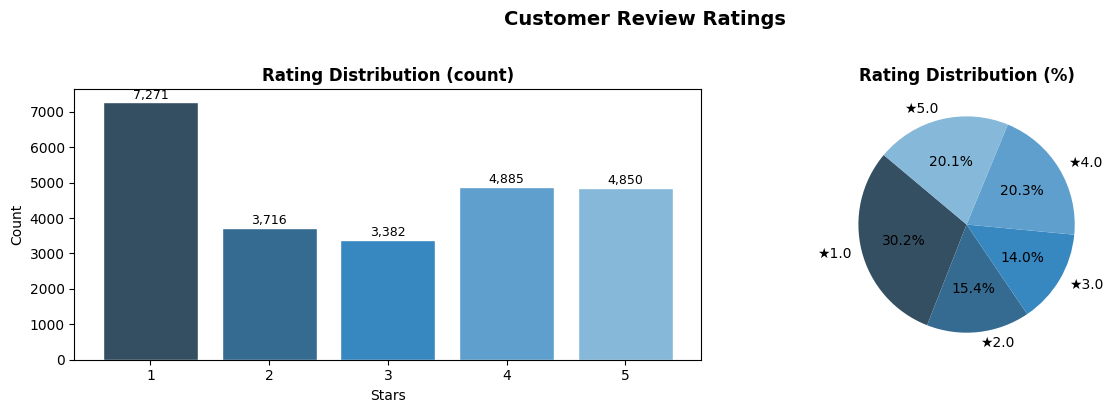

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Count plot
bars = axes[0].bar(note_counts.index, note_counts.values,
                   color=sns.color_palette("Blues_d", 5)[::-1], edgecolor="white")
axes[0].set_title("Rating Distribution (count)", fontweight="bold")
axes[0].set_xlabel("Stars"); axes[0].set_ylabel("Count")
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20, f"{bar.get_height():,}",
                 ha="center", va="bottom", fontsize=9)

# Pie chart
axes[1].pie(note_counts.values, labels=[f"★{i}" for i in note_counts.index],
            autopct="%1.1f%%", startangle=140,
            colors=sns.color_palette("Blues_d", 5)[::-1])
axes[1].set_title("Rating Distribution (%)", fontweight="bold")

plt.suptitle("Customer Review Ratings", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("visualizations/rating_distribution.png", bbox_inches="tight")
plt.show()

We can see that the majority of reviews are 1-star reviews which demonstrates the idea that clients mostly write a review when they are disappointed of an insurance product. It is then followed by 4 and 5 star reviews ratings.

### 3.2 Reviews per Insurer

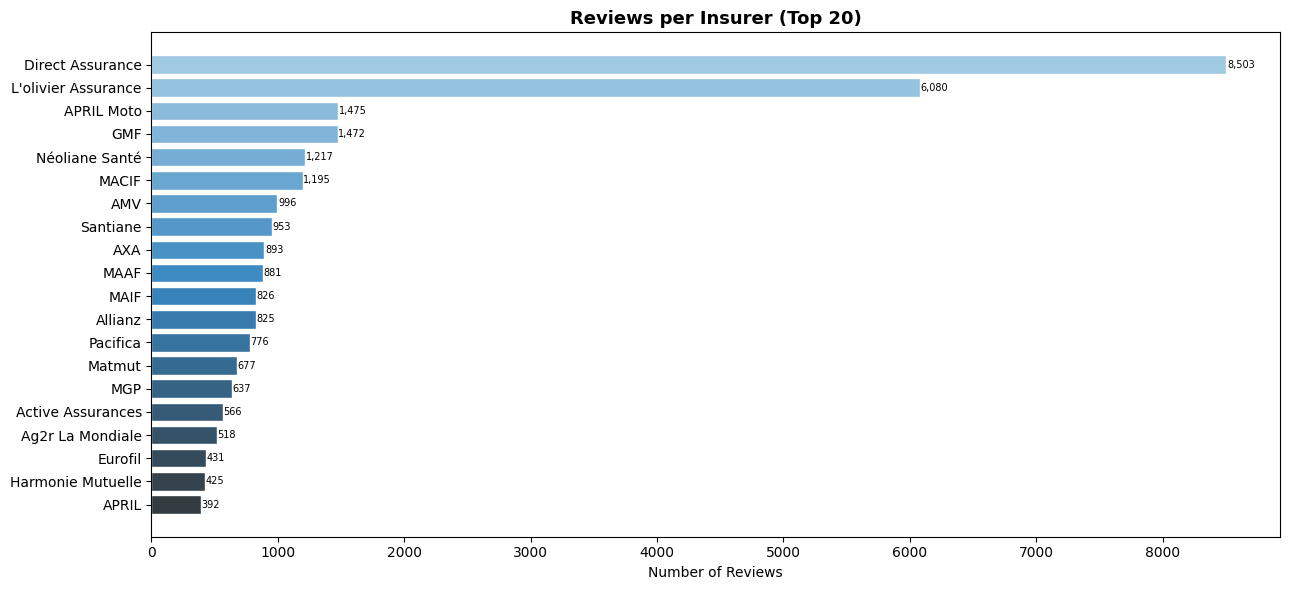

In [38]:
insurer_counts = df["assureur"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(13, 6))
colors = sns.color_palette("Blues_d", len(insurer_counts))
bars = ax.barh(insurer_counts.index, insurer_counts.values,
               color=colors, edgecolor="white")
ax.set_xlabel("Number of Reviews")
ax.set_title("Reviews per Insurer (Top 20)", fontweight="bold", fontsize=13)
ax.invert_yaxis()
for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():,.0f}", va="center", fontsize=7)
plt.tight_layout()
plt.savefig("visualizations/reviews_per_insurer.png", bbox_inches="tight")
plt.show()

### 3.3 Reviews per Product Type

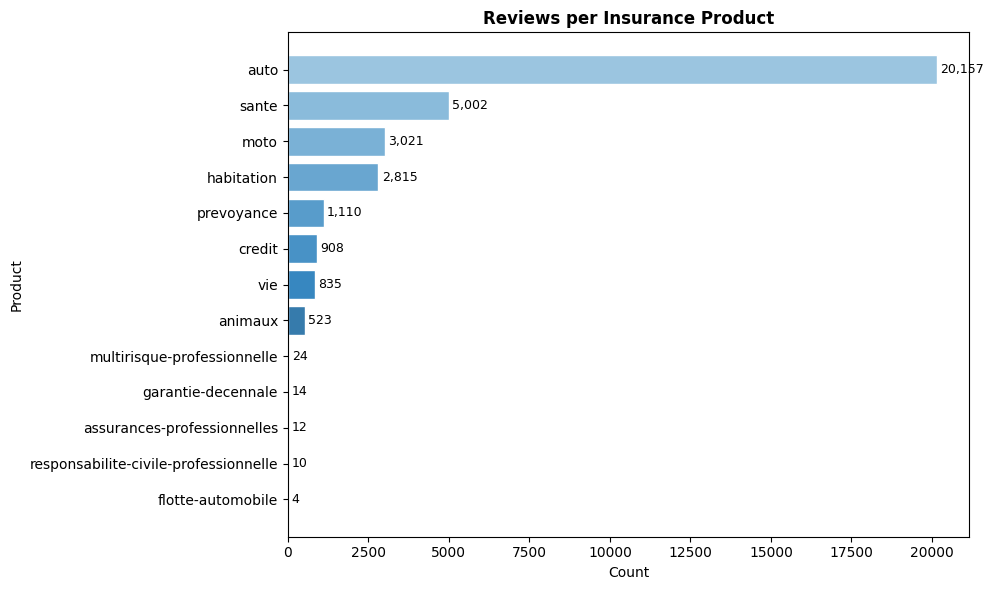

In [39]:
prod_counts = df["produit"].value_counts()

fig, ax = plt.subplots(figsize=(10, 6)) 

bars = ax.barh(prod_counts.index, prod_counts.values,
               color=sns.color_palette("Blues_d", len(prod_counts)),
               edgecolor="white")

ax.set_ylabel("Product")
ax.set_xlabel("Count")
ax.set_title("Reviews per Insurance Product", fontweight="bold")

ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(width + 100, 
            bar.get_y() + bar.get_height()/2, 
            f"{width:,.0f}", 
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig("visualizations/reviews_per_product_clean.png", bbox_inches="tight")
plt.show()

### 3.4 Average Rating per Insurer (top 20)

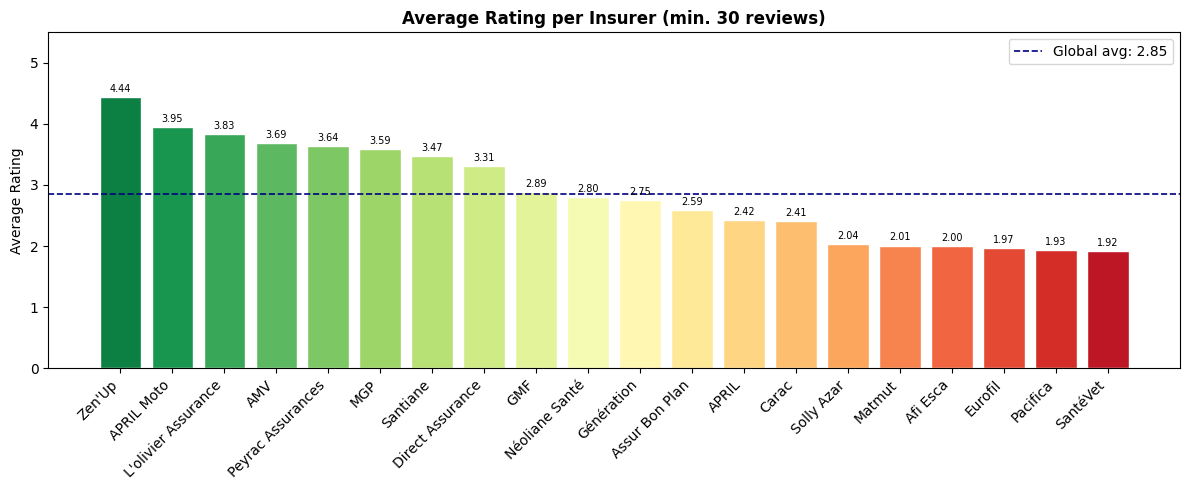

In [40]:
# Only insurers with at least 30 reviews for reliability
insurer_stats = (
    df.groupby("assureur")
    .agg(avg_note=("note", "mean"), count=("note", "size"))
    .query("count >= 30")
    .sort_values("avg_note", ascending=False)
    .head(20)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
palette = sns.color_palette("RdYlGn", len(insurer_stats))
bar_colors = [palette[i] for i in (insurer_stats["avg_note"].rank(method="first").astype(int)-1)]
bars = ax.bar(insurer_stats["assureur"], insurer_stats["avg_note"],
              color=bar_colors, edgecolor="white")
ax.axhline(df["note"].mean(), color="navy", linestyle="--", linewidth=1.2, label=f"Global avg: {df['note'].mean():.2f}")
ax.set_ylabel("Average Rating"); ax.set_ylim(0, 5.5)
ax.set_title("Average Rating per Insurer (min. 30 reviews)", fontweight="bold")
ax.tick_params(axis="x", rotation=45)
ax.legend()
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05, f"{bar.get_height():.2f}",
            ha="center", va="bottom", fontsize=7)
plt.tight_layout()
plt.xticks(ha='right')
plt.savefig("visualizations/avg_rating_insurer.png", bbox_inches="tight")
plt.show()

### 3.5 Review Length Analysis

/var/folders/cr/3y3t2vr97xsf_f_y_xhw2jv00000gn/T/ipykernel_94307/3112412227.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df[df["note"]==n]["review_len_words"].dropna() for n in [1,2,3,4,5]],


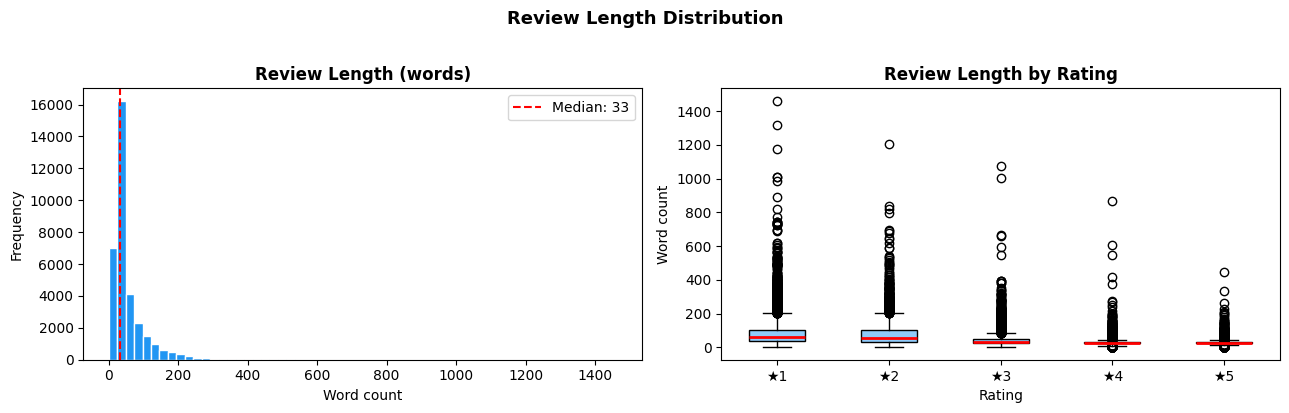

count    34435.0
mean        56.0
std         65.5
min          0.0
25%         26.0
50%         33.0
75%         62.0
max       1462.0
Name: review_len_words, dtype: float64


In [41]:
df["review_len_words"] = df["avis_en"].fillna("").str.split().str.len()
df["review_len_chars"] = df["avis_en"].fillna("").str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["review_len_words"], bins=60, color="#2196F3", edgecolor="white")
axes[0].axvline(df["review_len_words"].median(), color="red", linestyle="--",
                label=f"Median: {df['review_len_words'].median():.0f}")
axes[0].set_title("Review Length (words)", fontweight="bold")
axes[0].set_xlabel("Word count"); axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].boxplot([df[df["note"]==n]["review_len_words"].dropna() for n in [1,2,3,4,5]],
                labels=["★1","★2","★3","★4","★5"],
                patch_artist=True,
                boxprops=dict(facecolor="#90CAF9"),
                medianprops=dict(color="red", linewidth=2))
axes[1].set_title("Review Length by Rating", fontweight="bold")
axes[1].set_xlabel("Rating"); axes[1].set_ylabel("Word count")

plt.suptitle("Review Length Distribution", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("visualizations/review_length.png", bbox_inches="tight")
plt.show()

print(df["review_len_words"].describe().round(1))

### 3.6 Reviews Over Time

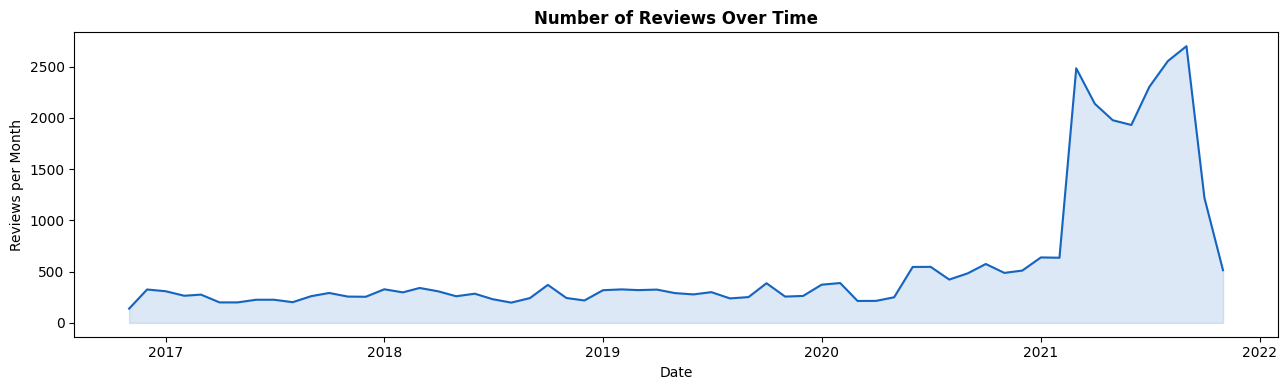

In [42]:
df["date_publication"] = pd.to_datetime(df["date_publication"], dayfirst=True, errors="coerce")
df["year_month"] = df["date_publication"].dt.to_period("M")

monthly = df.groupby("year_month").size().reset_index(name="count")
monthly["date"] = monthly["year_month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly["date"], monthly["count"], color="#1565C0", linewidth=1.5)
ax.fill_between(monthly["date"], monthly["count"], alpha=0.15, color="#1565C0")
ax.set_title("Number of Reviews Over Time", fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Reviews per Month")
plt.tight_layout()
plt.savefig("visualizations/reviews_over_time.png", bbox_inches="tight")
plt.show()

## 4. Frequent Words & N-grams

In [43]:
STOP_EN = set(stopwords.words("english"))
STOP_FR = set(stopwords.words("french"))
STOP_ALL = STOP_EN | STOP_FR | {"insurance", "assurance", "je", "c'est", "car"}

def tokenize_clean(text, language="en"):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)         # URLs
    text = re.sub(r"[^a-zA-Zàâäéèêëîïôùûüç\s]", " ", text)  # keep letters
    text = re.sub(r"\s+", " ", text).strip()
    tokens = word_tokenize(text)
    stop = STOP_EN if language == "en" else STOP_FR
    tokens = [t for t in tokens if t not in stop and len(t) > 2]
    return tokens

# Use English reviews for frequency analysis
tqdm.pandas(desc="Tokenizing")
df["tokens_en"] = df["avis_en"].progress_apply(lambda x: tokenize_clean(x, "en"))
print("Tokenization done")

Tokenizing: 100%|██████████| 34435/34435 [00:02<00:00, 11904.99it/s]

Tokenization done


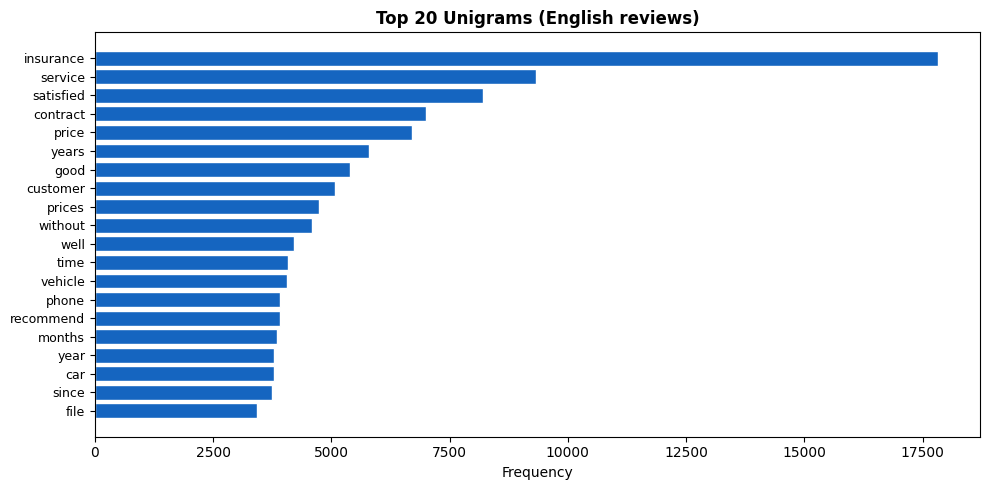

In [44]:
def plot_top_ngrams(token_series, n=1, top_k=20, title="Top Words",
                   color="#1565C0", fname=None):
    all_ngrams = []
    for tokens in token_series:
        if not tokens:
            continue
        grams = list(ngrams(tokens, n)) if n > 1 else tokens
        all_ngrams.extend(grams)

    counter = Counter(all_ngrams)
    if not counter:
        print(f"No n-grams found for n={n}")
        return

    labels, counts = zip(*counter.most_common(top_k))
    if n > 1:
        labels = [" ".join(g) for g in labels]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(range(len(labels)), counts, color=color, edgecolor="white")
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Frequency")
    plt.tight_layout()
    if fname:
        plt.savefig(fname, bbox_inches="tight")
    plt.show()

# Unigrams
plot_top_ngrams(
    df["tokens_en"],
    n=1,
    title="Top 20 Unigrams (English reviews)",
    color="#1565C0",
    fname="visualizations/top_unigrams.png",
)

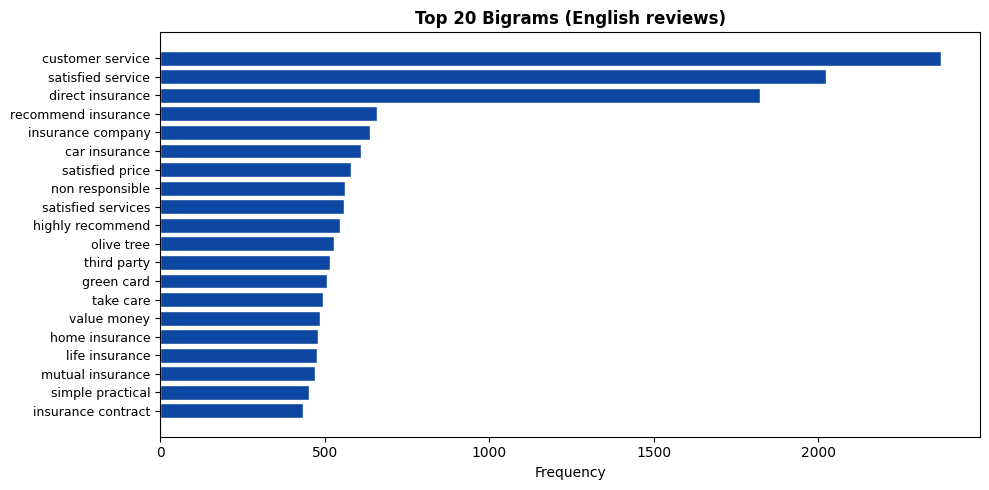

In [46]:
# Bigrams
plot_top_ngrams(
    df["tokens_en"],
    n=2,
    title="Top 20 Bigrams (English reviews)",
    color="#0D47A1",
    fname="visualizations/top_bigrams.png",
)

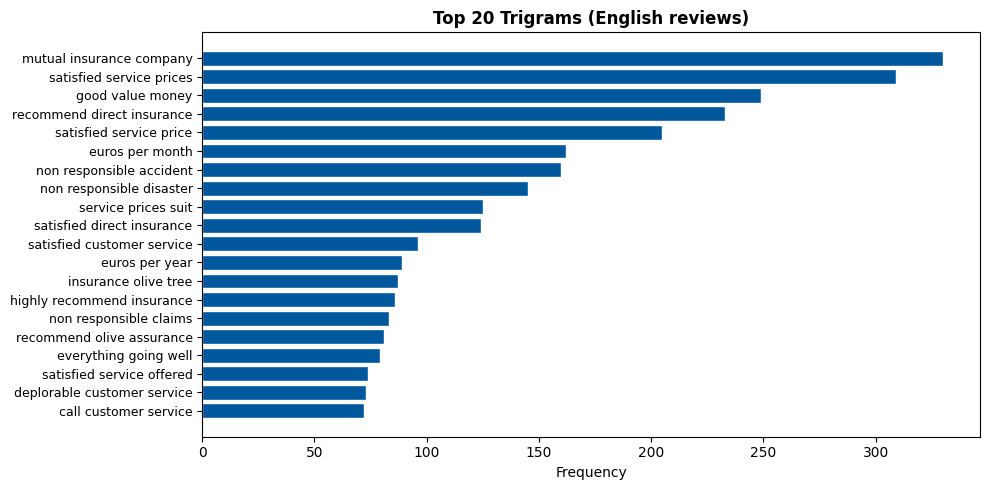

In [48]:
# Trigrams
plot_top_ngrams(
    df["tokens_en"],
    n=3,
    title="Top 20 Trigrams (English reviews)",
    color="#01579B",
    fname="visualizations/top_trigrams.png",
)

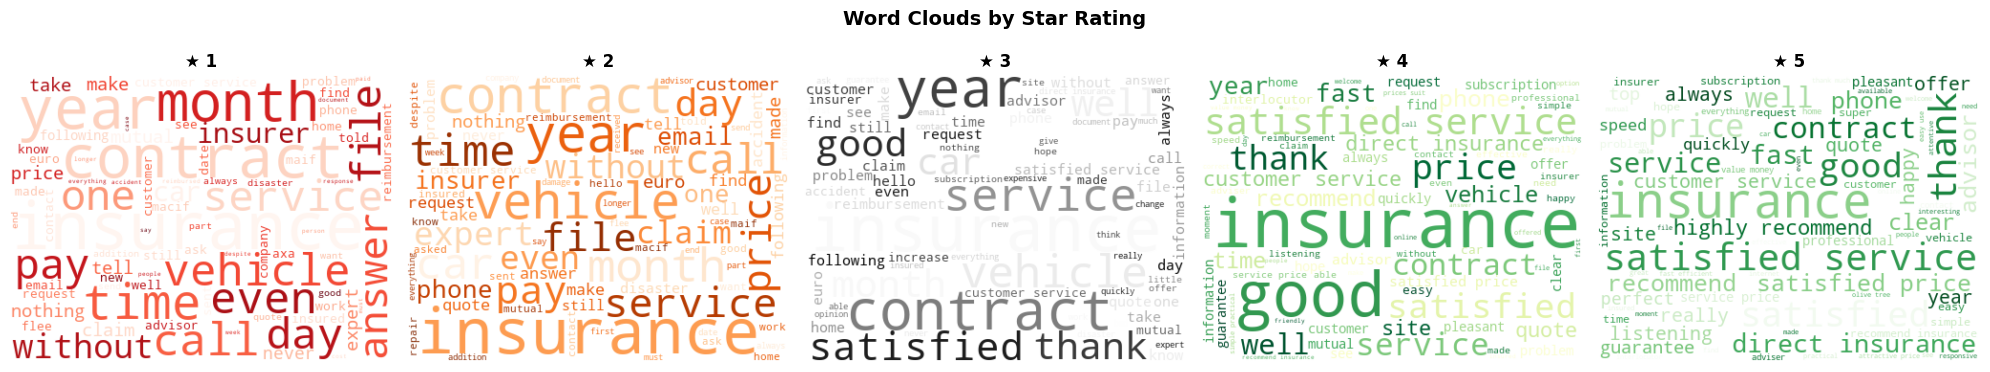

In [49]:
# ── Per-rating word clouds
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
rating_colors = {1: "Reds", 2: "Oranges", 3: "Greys", 4: "YlGn", 5: "Greens"}

for note, ax in zip([1, 2, 3, 4, 5], axes):
    subset = df[df["note"] == note]["tokens_en"]
    all_words = " ".join([w for tokens in subset if tokens for w in tokens])
    if not all_words.strip():
        ax.axis("off")
        ax.set_title(f"★ {note} (no data)", fontweight="bold")
        continue

    wc = WordCloud(
        width=400,
        height=300,
        background_color="white",
        colormap=rating_colors[note],
        max_words=80,
    ).generate(all_words)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"★ {note}", fontweight="bold")

plt.suptitle("Word Clouds by Star Rating", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("visualizations/wordclouds_by_rating.png", bbox_inches="tight")
plt.show()

## 5. Data Cleaning

### 5.1 Structural Cleaning

In this step we clean only the columns needed for analysis/modeling, using simple and explainable rules:
- Remove duplicate reviews using core scalar columns (not token list columns).
- Remove rows with empty/very short `avis`.
- Parse dates with `dayfirst=True` and `errors='coerce'` for robustness.
- Standardize text whitespace in key string columns.
- Convert `note` safely to numeric, then to integer.

In [59]:
before_rows = len(df)
print(f"Before cleaning: {before_rows:,} rows")

# Drop duplicates using only scalar columns (list columns like tokens_en are unhashable).
dedup_cols = [
    "note",
    "avis",
    "avis_en",
    "assureur",
    "produit",
    "type",
    "date_publication",
    "date_exp",
]
dedup_cols = [col for col in dedup_cols if col in df.columns]
df = df.drop_duplicates(subset=dedup_cols)

# Remove rows with missing/too-short review text
df = df.dropna(subset=["avis"])
df = df[df["avis"].astype(str).str.strip().str.len() > 5]

# Parse dates safely
df["date_publication"] = pd.to_datetime(df["date_publication"], dayfirst=True, errors="coerce")
if "date_exp" in df.columns:
    df["date_exp"] = pd.to_datetime(df["date_exp"], dayfirst=True, errors="coerce")

# Normalize whitespace in key string columns
str_cols = ["avis", "avis_en", "assureur", "produit", "type"]
for col in str_cols:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

# Normalize note safely (drop invalid values, then cast)
df["note"] = pd.to_numeric(df["note"], errors="coerce")
df = df.dropna(subset=["note"])
df["note"] = df["note"].astype(int)

# Reset index for clean downstream processing
df = df.reset_index(drop=True)

after_rows = len(df)
print(f"After cleaning: {after_rows:,} rows")
print(f"Rows removed during structural cleaning: {before_rows - after_rows:,}")

Before cleaning: 24,092 rows
After cleaning: 24,092 rows
Rows removed during structural cleaning: 0


### 5.2 Text Cleaning Function

In [52]:
def clean_text(text: str, language: str = "fr") -> str:
    """
    Light cleaning: normalises whitespace, removes URLs/emojis, fixes repeated characters, keeps punctuation.
    We preserve the original meaning for downstream NLP models.
    """
    if not isinstance(text, str):
        return ""

    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", "", text)

    # Remove emojis & non-printable characters
    text = text.encode("ascii", "ignore").decode("ascii")

    # Normalise whitespace and line breaks
    text = re.sub(r"[\r\n\t]+", " ", text)
    text = re.sub(r" {2,}", " ", text)

    # Fix repeated characters e.g. "trèèèès" → "très"
    text = re.sub(r"(.)\1{3,}", r"\1\1", text)

    # Fix run-on punctuation e.g. "!!!" → "!"
    text = re.sub(r"([!?.]){2,}", r"\1", text)

    return text.strip()

# Apply to French text
tqdm.pandas(desc="Cleaning French reviews")
df["avis_cor"] = df["avis"].progress_apply(lambda x: clean_text(x, "fr"))

print("Sample before/after:")
for i in range(min(3, len(df))):
    print(f"\nORIG: {df['avis'].iloc[i][:120]}")
    print(f"CLEAN: {df['avis_cor'].iloc[i][:120]}")

Cleaning French reviews: 100%|██████████| 34435/34435 [00:00<00:00, 57022.07it/s]

Sample before/after:

ORIG: Meilleurs assurances, prix, solutions, écoute, rapidité, et je recommande cette compagnie pour vous 
Des prix attractif 
CLEAN: Meilleurs assurances, prix, solutions, coute, rapidit, et je recommande cette compagnie pour vous Des prix attractif et 

ORIG: je suis globalement satisfait , sauf que vous avez un problème avec votre site internet ,impossible de déclarer un sinis
CLEAN: je suis globalement satisfait , sauf que vous avez un problme avec votre site internet ,impossible de dclarer un sinistr

ORIG: Prix tres abordable plusieurs options s'offrent a nous comme le boitier connecter à la voiture, l'option tranquiliter et
CLEAN: Prix tres abordable plusieurs options s'offrent a nous comme le boitier connecter la voiture, l'option tranquiliter et z


### 5.3 Spelling Correction

Spelling correction is computationally expensive on large datasets. 
For clarity and speed, we use a sample-based strategy:
1. Clean all rows with lightweight rules.
2. Apply costly correction models only on a sample.
3. Keep the notebook reproducible and fast for classroom/demo use.

In [53]:
# ── NOTE: Spelling correction is slow on 35k rows.
# We apply it to the *English* column (TextBlob works best in English).
# For production, use `pyspellchecker` or `autocorrect` on French text.

def correct_spelling_en(text: str) -> str:
    """
    Correct spelling using TextBlob (English only).
    Skips very short or empty strings.
    """
    if not isinstance(text, str) or len(text.split()) < 3:
        return str(text)
    try:
        return str(TextBlob(text).correct())
    except Exception:
        return text

# ── Apply on a sample to demo; comment the [sample_idx] to run on all rows ──
SAMPLE_SIZE = 200   # set to len(df) to run on full dataset (slow!)
sample_idx = df.sample(SAMPLE_SIZE, random_state=42).index

tqdm.pandas(desc="Spelling correction (sample)")
df.loc[sample_idx, "avis_cor_en"] = df.loc[sample_idx, "avis_en"].progress_apply(
    correct_spelling_en
)

# For rows not in the sample, just copy clean avis_en as placeholder
df["avis_cor_en"] = df["avis_cor_en"].fillna(df["avis_en"].apply(clean_text))

print("\nSpelling correction done ✓")
print("\nBefore/after examples:")
for idx in list(sample_idx)[:3]:
    before = df.loc[idx, "avis_en"][:100]
    after  = df.loc[idx, "avis_cor_en"][:100]
    if before != after:
        print(f"\n  BEFORE: {before}")
        print(f"  AFTER:  {after}")


Spelling correction (sample): 100%|██████████| 200/200 [00:16<00:00, 11.82it/s]



Spelling correction done ✓

Before/after examples:

  BEFORE: Hot Line totally rotten and in bad faith intended to abandon requests
Delai Average Hot Line Moving 
  AFTER:  Not Line totally rotten and in bad faith intended to abandon requests
Delay Average Not Line Moving 


In [57]:
def spelling_correction(text: str, lang: str) -> str:
    # Simple, explainable spell correction function
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)

    if lang == "fr":
        stop_words = STOP_WORDS_FR
        model = MODEL_CORRECTION_FR
        language = "french"
    elif lang == "en":
        stop_words = STOP_WORDS_EN
        model = MODEL_CORRECTION_EN
        language = "english"
    else:
        return text

    tokens = word_tokenize(text, language=language)
    corrected_words = []

    for word in tokens:
        # Skip correction for non-alphabetic or very short tokens to keep runtime reasonable
        if not word.isalpha() or len(word) <= 2:
            continue

        corrected_word = model.correction(word)
        final_word = corrected_word if corrected_word else word

        if final_word not in stop_words:
            corrected_words.append(final_word)

    return " ".join(corrected_words)

In [58]:
df_train = df[df["type"] == "train"].copy()
df_test = df[df["type"] == "test"].copy()

# Sample-based correction for speed
SAMPLE_SIZE_TRAIN = min(1000, len(df_train))
sample_idx_train = df_train.sample(SAMPLE_SIZE_TRAIN, random_state=42).index

# Start from lightly cleaned text for all rows
df_train["avis_cor"] = df_train["avis"].apply(lambda x: clean_text(x, "fr"))
df_train["avis_cor_en"] = df_train["avis_en"].apply(lambda x: clean_text(x, "en"))

# Apply expensive spelling correction on sample only
tqdm.pandas(desc="Spelling correction train sample")
df_train.loc[sample_idx_train, "avis_cor"] = df_train.loc[sample_idx_train, "avis"].progress_apply(
    lambda x: spelling_correction(x, lang="fr")
)
df_train.loc[sample_idx_train, "avis_cor_en"] = df_train.loc[sample_idx_train, "avis_en"].progress_apply(
    lambda x: spelling_correction(x, lang="en")
)

# Save cleaned training data
df_train.to_excel(DATA_PATH / "train_dataset.xlsx", index=False, sheet_name="Avis Corrigés")
print(f"Saved train_dataset.xlsx with sample-corrected rows: {SAMPLE_SIZE_TRAIN:,}")

Spelling correction train sample: 100%|██████████| 1000/1000 [00:44<00:00, 22.56it/s]


Saved train_dataset.xlsx with sample-corrected rows: 1,000


### Conclusion

My conclusion

# Next